<a href="https://colab.research.google.com/github/jcmachicao/modelamiento_computacional/blob/main/U2__modeling_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random

In [ ]:
# Cognitive Simulator Demonstration
import random
import matplotlib.pyplot as plt

class CognitiveAgent:
    def __init__(self, initial_belief=0.3):
        self.belief_danger = initial_belief
        self.state = "calm"
        self.memory = []

    # Bayes
    def update_belief(self, evidence):
        likelihood = {
            "strong_signal": 0.8,
            "weak_signal": 0.5,
            "none": 0.1
        }

        p_e_given_d = likelihood[evidence]
        p_d = self.belief_danger

        posterior = (p_e_given_d * p_d) / (
            p_e_given_d * p_d + (1 - p_e_given_d) * (1 - p_d)
        )

        self.belief_danger = posterior

    # Markov
    def transition_state(self):
        if self.state == "calm":
            if random.random() < self.belief_danger:
                self.state = "alert"
        else:
            if random.random() > self.belief_danger:
                self.state = "calm"

    # Monte Carlo
    def simulate_future(self, simulations=500):
        danger_count = 0
        for _ in range(simulations):
            if random.random() < self.belief_danger:
                danger_count += 1
        return danger_count / simulations

    def perceive(self, evidence):
        self.update_belief(evidence)
        self.transition_state()
        simulated_risk = self.simulate_future()
        self.memory.append((evidence, self.belief_danger, self.state, simulated_risk))

SCENARIO 1: Escalating Threat

Step 1 | Evidence: none | Belief: 0.027 | State: calm | Simulated Risk: 0.040
Step 2 | Evidence: weak_signal | Belief: 0.027 | State: calm | Simulated Risk: 0.014
Step 3 | Evidence: weak_signal | Belief: 0.027 | State: calm | Simulated Risk: 0.022
Step 4 | Evidence: strong_signal | Belief: 0.100 | State: calm | Simulated Risk: 0.106
Step 5 | Evidence: strong_signal | Belief: 0.308 | State: alert | Simulated Risk: 0.292


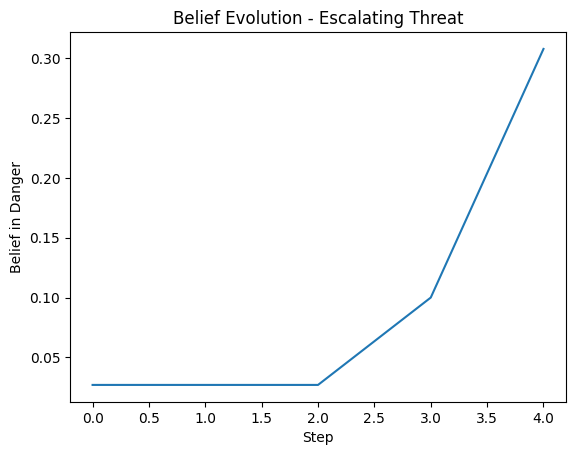

In [ ]:
# -----------------------------
# SCENARIO 1: Escalating Threat
# -----------------------------
agent1 = CognitiveAgent(initial_belief=0.2)

sequence1 = ["none", "weak_signal", "weak_signal", "strong_signal", "strong_signal"]

print("SCENARIO 1: Escalating Threat\n")
for step, evidence in enumerate(sequence1, 1):
    agent1.perceive(evidence)
    print(f"Step {step} | Evidence: {evidence} | Belief: {agent1.belief_danger:.3f} | State: {agent1.state} | Simulated Risk: {agent1.memory[-1][3]:.3f}")

beliefs1 = [m[1] for m in agent1.memory]

plt.figure()
plt.plot(beliefs1)
plt.title("Belief Evolution - Escalating Threat")
plt.xlabel("Step")
plt.ylabel("Belief in Danger")
plt.show()

In [ ]:
beliefs1

[0.02702702702702703,
 0.02702702702702703,
 0.02702702702702703,
 0.10000000000000002,
 0.30769230769230776]


SCENARIO 2: Decreasing Threat

Step 1 | Evidence: strong_signal | Belief: 0.941 | State: alert | Simulated Risk: 0.932
Step 2 | Evidence: weak_signal | Belief: 0.941 | State: alert | Simulated Risk: 0.932
Step 3 | Evidence: none | Belief: 0.640 | State: calm | Simulated Risk: 0.650
Step 4 | Evidence: none | Belief: 0.165 | State: calm | Simulated Risk: 0.170
Step 5 | Evidence: none | Belief: 0.021 | State: calm | Simulated Risk: 0.024


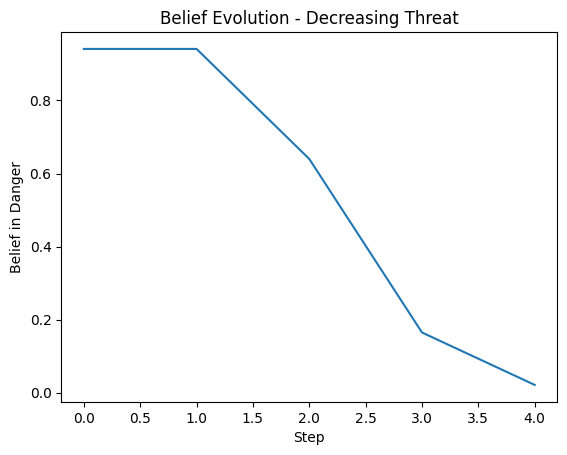

In [ ]:
# -----------------------------
# SCENARIO 2: Decreasing Threat
# -----------------------------
agent2 = CognitiveAgent(initial_belief=0.8)

sequence2 = ["strong_signal", "weak_signal", "none", "none", "none"]

print("\nSCENARIO 2: Decreasing Threat\n")
for step, evidence in enumerate(sequence2, 1):
    agent2.perceive(evidence)
    print(f"Step {step} | Evidence: {evidence} | Belief: {agent2.belief_danger:.3f} | State: {agent2.state} | Simulated Risk: {agent2.memory[-1][3]:.3f}")

beliefs2 = [m[1] for m in agent2.memory]

plt.figure()
plt.plot(beliefs2)
plt.title("Belief Evolution - Decreasing Threat")
plt.xlabel("Step")
plt.ylabel("Belief in Danger")
plt.show()